# 17. 탐색적 데이터 분석 (EDA) 종합 프로젝트

## 학습 목표
- 실무 시나리오에 맞춰 **EDA 프로세스 전체**를 수행한다
- 데이터 개요 → 품질 확인 → 전처리 → 분석 → 인사이트 도출 순서로 작업한다
- 지금까지 배운 Pandas / 시각화 기술을 **한 프로젝트에 통합 적용**한다

---

## 시나리오

이커머스 플랫폼의 주문 데이터(`ecommerce.csv`)를 분석하여 **비즈니스 인사이트**를 찾습니다.

### EDA 표준 프로세스
1. **데이터 개요 파악**: shape, columns, 샘플, 타입
2. **품질 확인**: 결측치, 중복, 이상치
3. **전처리**: 타입 변환, 결측 처리, 파생 컬럼
4. **분석**: 시계열, 카테고리, 고객, 상관관계
5. **인사이트 정리**


In [1]:
# 아래에 코드를 작성하세요
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

---
## 1. 데이터 개요 파악


In [2]:
# 아래에 코드를 작성하세요
# ecommerce.csv 파일을 읽어오세요
df = pd.read_csv('./data/ecommerce.csv')

In [3]:
# 아래에 코드를 작성하세요
# 몇행 몇열인지 확인하세요.
df.shape

(2000, 15)

In [4]:
# 아래에 코드를 작성하세요
# 각 컬럼의 데이터 타입을 확인하세요.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   주문ID    2000 non-null   object 
 1   주문일자    2000 non-null   object 
 2   고객ID    2000 non-null   object 
 3   성별      2000 non-null   object 
 4   연령      1975 non-null   float64
 5   지역      2000 non-null   object 
 6   유입채널    2000 non-null   object 
 7   카테고리    2000 non-null   object 
 8   상품명     2000 non-null   object 
 9   단가      1985 non-null   float64
 10  수량      2000 non-null   int64  
 11  할인율     2000 non-null   float64
 12  결제방법    2000 non-null   object 
 13  주문상태    2000 non-null   object 
 14  평점      1296 non-null   float64
dtypes: float64(4), int64(1), object(10)
memory usage: 234.5+ KB


In [5]:
df

,주문ID,주문일자,고객ID,성별,연령,지역,유입채널,카테고리,상품명,단가,수량,할인율,결제방법,주문상태,평점
0,ORD00001,2023-01-01,CUST0100,남,52.0,대구,이메일,의류,티셔츠,NaN,3,0.05,포인트,취소,NaN
1,ORD00002,2023-01-01,CUST0080,남,35.0,경기,SNS,뷰티,립스틱,128000.0,1,0.00,계좌이체,배송완료,4.0
2,ORD00003,2023-01-01,CUST0045,여,29.0,제주,SNS,뷰티,스킨케어세트,34000.0,3,0.05,신용카드,배송중,NaN
3,ORD00004,2023-01-02,CUST0141,남,35.0,인천,SNS,뷰티,선크림,30000.0,2,0.30,신용카드,배송완료,4.0
4,ORD00005,2023-01-04,CUST0136,남,37.0,서울,검색,생활용품,쿠션,17000.0,1,0.30,신용카드,배송완료,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,ORD01996,2024-12-31,CUST0045,여,51.0,대전,SNS,전자기기,충전기,208000.0,2,0.20,신용카드,배송완료,5.0
1996,ORD01997,2024-12-31,CUST0049,남,28.0,세종,이메일,의류,티셔츠,81000.0,2,0.20,간편결제,취소,NaN
1997,ORD01998,2024-12-31,CUST0051,여,49.0,부산,검색,의류,티셔츠,54000.0,2,0.00,간편결제,배송완료,4.0
1998,ORD01999,2024-12-31,CUST0019,남,36.0,경기,이메일,전자기기,이어폰,86000.0,1,0.30,간편결제,배송완료,5.0


In [6]:
df.head()

,주문ID,주문일자,고객ID,성별,연령,지역,유입채널,카테고리,상품명,단가,수량,할인율,결제방법,주문상태,평점
0,ORD00001,2023-01-01,CUST0100,남,52.0,대구,이메일,의류,티셔츠,NaN,3,0.05,포인트,취소,NaN
1,ORD00002,2023-01-01,CUST0080,남,35.0,경기,SNS,뷰티,립스틱,128000.0,1,0.00,계좌이체,배송완료,4.0
2,ORD00003,2023-01-01,CUST0045,여,29.0,제주,SNS,뷰티,스킨케어세트,34000.0,3,0.05,신용카드,배송중,NaN
3,ORD00004,2023-01-02,CUST0141,남,35.0,인천,SNS,뷰티,선크림,30000.0,2,0.30,신용카드,배송완료,4.0
4,ORD00005,2023-01-04,CUST0136,남,37.0,서울,검색,생활용품,쿠션,17000.0,1,0.30,신용카드,배송완료,5.0


In [7]:
# 주문일자는 언제부터 언제까지의 데이터일까?
# 유입채널은 어떤 종류들이 있나?
# 결제방법은 어떤 종류들이 있나?
# 주문상태는 어떤 종류들이 있나?

In [6]:
df['주문일자'].min()

'2023-01-01'

In [7]:
df['주문일자'].max()

'2024-12-31'

In [8]:
df['유입채널'].unique()

array(['이메일', 'SNS', '검색', '직접방문', '제휴'], dtype=object)

In [14]:
df['결제방법'].unique()

array(['포인트', '계좌이체', '신용카드', '간편결제'], dtype=object)

In [15]:
df['주문상태'].unique()

array(['취소', '배송완료', '배송중', '반품'], dtype=object)

---
## 2. 품질 확인 - 결측치 / 중복 / 이상치


In [10]:
# 아래에 코드를 작성하세요
# 각 컬럼별 결측치를 확인하세요.
df.isna().sum()

주문ID      0
주문일자      0
고객ID      0
성별        0
연령       25
지역        0
유입채널      0
카테고리      0
상품명       0
단가       15
수량        0
할인율       0
결제방법      0
주문상태      0
평점      704
dtype: int64

In [11]:
# 아래에 코드를 작성하세요
# 중복 데이터가 있는 확인하세요.
# 행 자체가 완전히 똑같은것은 없다.
df.duplicated().sum()

np.int64(0)

In [12]:
# 주문ID 만 똑같은게 있는지도 확인.
df.duplicated( subset= [ '주문ID' ] ).sum()

np.int64(0)

---
## 3. 전처리


In [13]:
df.head(2)

,주문ID,주문일자,고객ID,성별,연령,지역,유입채널,카테고리,상품명,단가,수량,할인율,결제방법,주문상태,평점
0,ORD00001,2023-01-01,CUST0100,남,52.0,대구,이메일,의류,티셔츠,NaN,3,0.05,포인트,취소,NaN
1,ORD00002,2023-01-01,CUST0080,남,35.0,경기,SNS,뷰티,립스틱,128000.0,1,0.00,계좌이체,배송완료,4.0


In [24]:
# 주문일자가 날짜형식인지 확인한 후에
# 아니면, 날짜 형식으로 바꿔준다.

In [14]:
df['주문일자'] = pd.to_datetime(  df['주문일자'] )

In [15]:
# 결측치가 있었다.
# 연령은 중앙값으로 채우자.
df['연령'].median()

35.0

In [16]:
df['연령'] = df['연령'].fillna( df['연령'].median() )

In [ ]:
# 평점은 0으로 채우자

In [17]:
df['평점'] = df['평점'].fillna(0)

In [18]:
# 단가도 채울건데....
df.head()

,주문ID,주문일자,고객ID,성별,연령,지역,유입채널,카테고리,상품명,단가,수량,할인율,결제방법,주문상태,평점
0,ORD00001,2023-01-01,CUST0100,남,52.0,대구,이메일,의류,티셔츠,NaN,3,0.05,포인트,취소,0.0
1,ORD00002,2023-01-01,CUST0080,남,35.0,경기,SNS,뷰티,립스틱,128000.0,1,0.00,계좌이체,배송완료,4.0
2,ORD00003,2023-01-01,CUST0045,여,29.0,제주,SNS,뷰티,스킨케어세트,34000.0,3,0.05,신용카드,배송중,0.0
3,ORD00004,2023-01-02,CUST0141,남,35.0,인천,SNS,뷰티,선크림,30000.0,2,0.30,신용카드,배송완료,4.0
4,ORD00005,2023-01-04,CUST0136,남,37.0,서울,검색,생활용품,쿠션,17000.0,1,0.30,신용카드,배송완료,5.0


In [19]:
df.groupby('카테고리')['단가'].mean()

카테고리
뷰티       79516.709512
생활용품     35515.068493
식품       46518.309859
의류       67596.602972
전자기기    176824.691358
Name: 단가, dtype: float64

In [20]:
df.groupby('카테고리')['단가'].transform('mean')

0        67596.602972
1        79516.709512
2        79516.709512
3        79516.709512
4        35515.068493
            ...      
1995    176824.691358
1996     67596.602972
1997     67596.602972
1998    176824.691358
1999     35515.068493
Name: 단가, Length: 2000, dtype: float64

In [21]:
df['단가'] = df['단가'].fillna(  df.groupby('카테고리')['단가'].transform('mean')  )

In [22]:
df.isna().sum()

주문ID    0
주문일자    0
고객ID    0
성별      0
연령      0
지역      0
유입채널    0
카테고리    0
상품명     0
단가      0
수량      0
할인율     0
결제방법    0
주문상태    0
평점      0
dtype: int64

In [23]:
# 파생 컬럼 만들기
# 매출 컬럼을 만드세요.  단가 X 수량 X ( 1-할인율) 
df['매출'] = df['단가'] * df['수량'] * ( 1 - df['할인율'] )

In [24]:
df.head(2)

,주문ID,주문일자,고객ID,성별,연령,지역,유입채널,카테고리,상품명,단가,수량,할인율,결제방법,주문상태,평점,매출
0,ORD00001,2023-01-01,CUST0100,남,52.0,대구,이메일,의류,티셔츠,67596.602972,3,0.05,포인트,취소,0.0,192650.318471
1,ORD00002,2023-01-01,CUST0080,남,35.0,경기,SNS,뷰티,립스틱,128000.000000,1,0.00,계좌이체,배송완료,4.0,128000.000000


In [25]:
# 월별 분석을 위해서, 월 컬럼만 따로 필요합니다.
df['월'] = df['주문일자'].dt.month

In [26]:
# 요일별 분석을 위해서, 요일 컬럼만 따로 필요합니다.
df['요일'] = df['주문일자'].dt.dayofweek

In [27]:
df.head()

,주문ID,주문일자,고객ID,성별,연령,지역,유입채널,카테고리,상품명,단가,수량,할인율,결제방법,주문상태,평점,매출,월,요일
0,ORD00001,2023-01-01,CUST0100,남,52.0,대구,이메일,의류,티셔츠,67596.602972,3,0.05,포인트,취소,0.0,192650.318471,1,6
1,ORD00002,2023-01-01,CUST0080,남,35.0,경기,SNS,뷰티,립스틱,128000.000000,1,0.00,계좌이체,배송완료,4.0,128000.000000,1,6
2,ORD00003,2023-01-01,CUST0045,여,29.0,제주,SNS,뷰티,스킨케어세트,34000.000000,3,0.05,신용카드,배송중,0.0,96900.000000,1,6
3,ORD00004,2023-01-02,CUST0141,남,35.0,인천,SNS,뷰티,선크림,30000.000000,2,0.30,신용카드,배송완료,4.0,42000.000000,1,0
4,ORD00005,2023-01-04,CUST0136,남,37.0,서울,검색,생활용품,쿠션,17000.000000,1,0.30,신용카드,배송완료,5.0,11900.000000,1,2


In [38]:
df['연령대'] = (df['연령'] // 10 * 10).astype(int).astype(str) + '대'

In [39]:
df.head(2)

,주문ID,주문일자,고객ID,성별,연령,지역,유입채널,카테고리,상품명,단가,수량,할인율,결제방법,주문상태,평점,매출,월,요일,연령대
0,ORD00001,2023-01-01,CUST0100,남,52.0,대구,이메일,의류,티셔츠,67596.602972,3,0.05,포인트,취소,0.0,192650.318471,1,6,50대
1,ORD00002,2023-01-01,CUST0080,남,35.0,경기,SNS,뷰티,립스틱,128000.000000,1,0.00,계좌이체,배송완료,4.0,128000.000000,1,6,30대


---
## 4. 분석

### 4-1. 시계열 매출 추이


In [40]:
df.to_csv('./data/ecommerce_all.csv')

In [41]:
# 월별 매출 추이를 보고 싶다.
# 판다스 데이터프레임으로 먼저 작업한다.
# 데이터프레임 작업이 다 끝나면 차트로 보여준다.

In [46]:
df_1 = df.groupby('월')['매출'].sum().round(0)

In [47]:
df_1

월
1     22939050.0
2     18404227.0
3     17332479.0
4     19594450.0
5     19794650.0
6     18033495.0
7     20307720.0
8     16827275.0
9     23884926.0
10    18552843.0
11    19200000.0
12    25239750.0
Name: 매출, dtype: float64

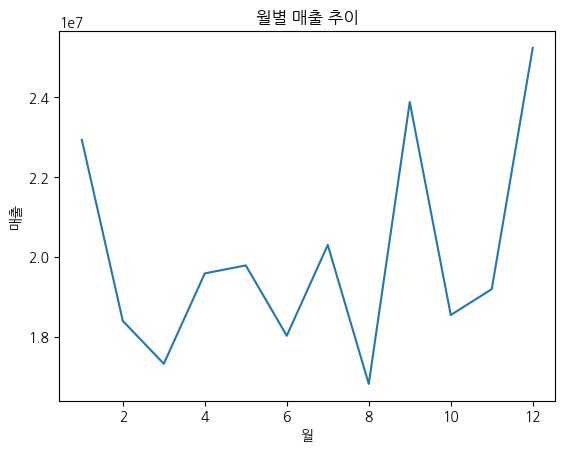

In [52]:
plt.plot(df_1.index , df_1.values )
plt.title('월별 매출 추이')
plt.xlabel('월')
plt.ylabel('매출')
plt.show()

### 4-2. 카테고리 분석

In [55]:
# 카테고리별 총 매출 
df_2 = df.groupby('카테고리')['매출'].sum()

In [62]:
df_2 = df_2.sort_values(ascending=False)

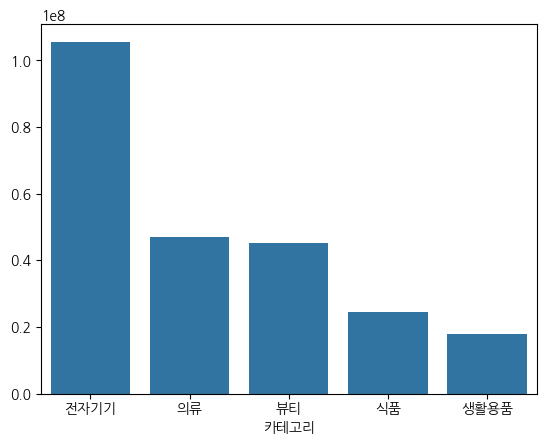

In [63]:
sns.barplot(x=df_2.index, y=df_2.values)
plt.show()

### 4-3. 고객 분석 (연령대, 성별, 지역)

In [ ]:
# 연령대 별 매출총합
# 성별 매출총합
# 지역별 매출총합

# 하나의 차트 영역에 3개를 보여주자. 1행 3열짜리 차트를 그리자.

In [66]:
df_3 = df.groupby('연령대')['매출'].sum()

In [68]:
df_4 = df.groupby('성별')['매출'].sum()

In [79]:
df_4 = df_4[ 1 : ]

In [80]:
df_5 = df.groupby('지역')['매출'].sum()

In [89]:
df_5 = df_5.sort_values(ascending=False)

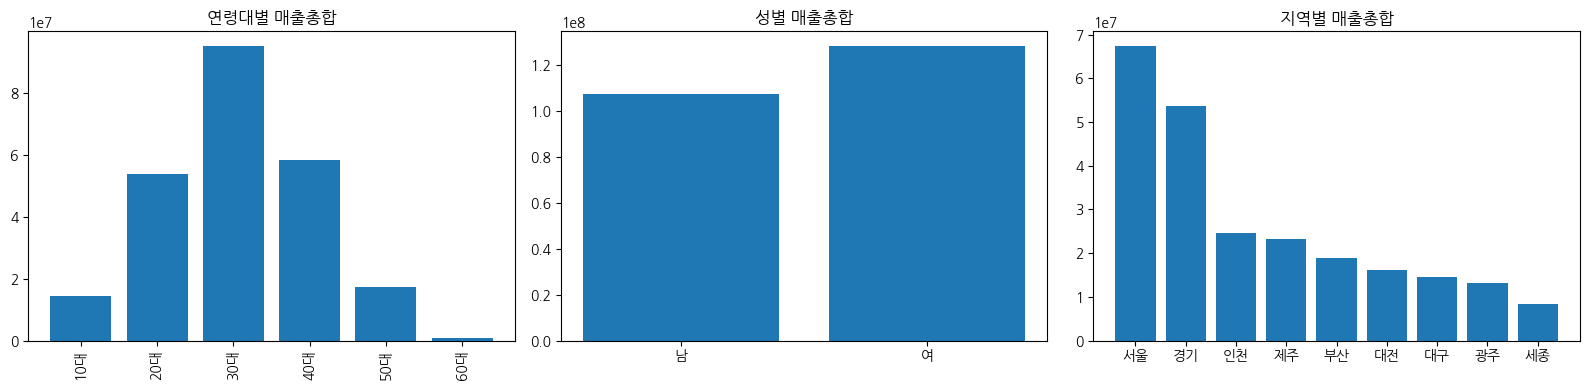

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
axes[0].bar(df_3.index, df_3.values)
axes[0].set_title('연령대별 매출총합')
axes[0].tick_params(axis = 'x', rotation=90)

axes[1].bar(df_4.index, df_4.values)
axes[1].set_title('성별 매출총합')

axes[2].bar(df_5.index, df_5.values)
axes[2].set_title('지역별 매출총합')

plt.tight_layout()
plt.show()

### 4-4. 상관관계 분석

In [ ]:
# 연령, 단가, 수량, 할인율, 매출, 평점

In [95]:
df_6 = df[['연령','단가','수량','할인율','매출','평점']].corr()

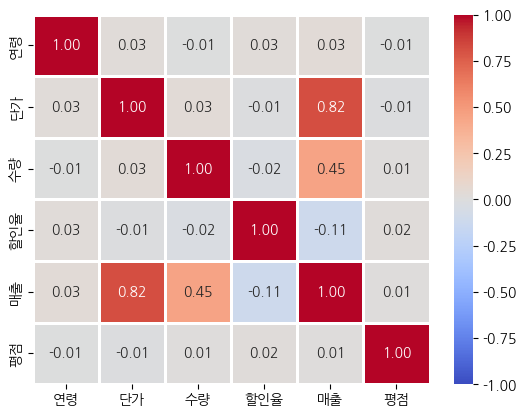

In [99]:
sns.heatmap(data= df_6, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f',linewidths=0.8)
plt.show()

In [ ]:
# 아래에 코드를 작성하세요


---
## 5. 인사이트 정리 (예시)

위 분석을 바탕으로 아래와 같은 인사이트를 정리할 수 있습니다.

1. **매출 추이**: 특정 월에 매출이 급격히 늘거나 줄었는지 확인
2. **주력 카테고리**: 매출 상위 카테고리에 마케팅 리소스 집중
3. **타깃 고객층**: 연령대/성별/지역별 매출 상위 그룹 파악
4. **할인 효과**: 할인율과 매출/수량의 상관관계 확인
5. **고객 만족**: 평점과 주요 변수 관계 파악

> 실무에서는 이런 인사이트를 **액션 아이템**(예: "30대 여성 뷰티 카테고리 타깃 광고 집행") 으로 연결합니다.


---
## 실습문제

### 문제 1. 취소/반품 분석

`주문상태` 컬럼을 사용해:
1. 주문상태별 건수와 비율(%)을 구하세요.
2. 취소된 주문이 가장 많은 카테고리 Top 3를 찾으세요.
3. 결과를 막대그래프로 시각화하세요.


In [102]:
df['주문상태'].unique()

array(['취소', '배송완료', '배송중', '반품'], dtype=object)

In [107]:
df_1 = df['주문상태'].value_counts()

In [110]:
df_2 = df['주문상태'].value_counts(normalize=True) * 100

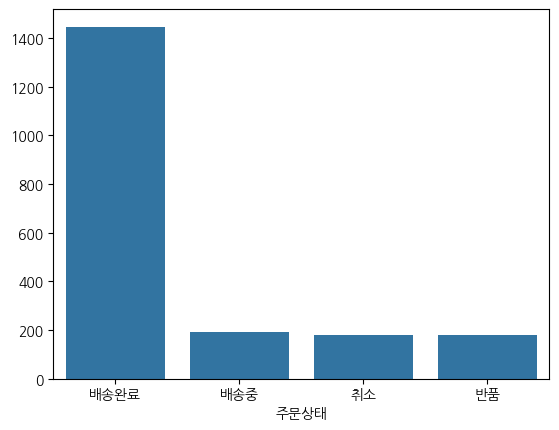

In [109]:
sns.barplot(x=df_1.index, y=df_1.values )
plt.show()

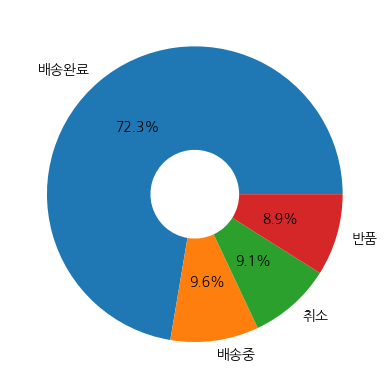

In [118]:
plt.pie(df_2, labels=df_2.index, autopct='%.1f%%', wedgeprops={'width':0.7})
plt.show()

In [119]:
# 주문상태가 취소인것만 가져오자

In [124]:
df_4 = df[ df['주문상태'] == '취소' ]

In [129]:
df_5 = df_4['카테고리'].value_counts().head(3)

In [130]:
df_5

카테고리
의류      47
전자기기    40
뷰티      38
Name: count, dtype: int64

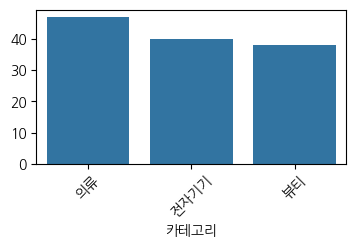

In [136]:
plt.figure(figsize=(4,2))
sns.barplot(x=df_5.index, y = df_5.values)
plt.xticks(rotation=45)
plt.show()

### 문제 2. 할인율 구간별 매출

1. `할인율`을 `0, 0.05, 0.1, 0.2, 0.3, 1.0` 구간으로 나눠 `할인구간` 컬럼을 만드세요.
   > 힌트: `pd.cut(df["할인율"], bins=[...], right=False)`
2. 할인구간별 주문 건수와 평균 매출을 구하세요.


In [140]:
df['할인율'].describe()

count    2000.000000
mean        0.100075
std         0.098380
min         0.000000
25%         0.000000
50%         0.100000
75%         0.150000
max         0.300000
Name: 할인율, dtype: float64

In [142]:
df['할인구간'] = pd.cut( df['할인율'], bins = [0, 0.05, 0.1, 0.2, 0.3, 1.0], right=False )

In [143]:
df.head()

,주문ID,주문일자,고객ID,성별,연령,지역,유입채널,카테고리,상품명,단가,수량,할인율,결제방법,주문상태,평점,매출,월,요일,연령대,할인구간
0,ORD00001,2023-01-01,CUST0100,남,52.0,대구,이메일,의류,티셔츠,67596.602972,3,0.05,포인트,취소,0.0,192650.318471,1,6,50대,"[0.05, 0.1)"
1,ORD00002,2023-01-01,CUST0080,남,35.0,경기,SNS,뷰티,립스틱,128000.000000,1,0.00,계좌이체,배송완료,4.0,128000.000000,1,6,30대,"[0.0, 0.05)"
2,ORD00003,2023-01-01,CUST0045,여,29.0,제주,SNS,뷰티,스킨케어세트,34000.000000,3,0.05,신용카드,배송중,0.0,96900.000000,1,6,20대,"[0.05, 0.1)"
3,ORD00004,2023-01-02,CUST0141,남,35.0,인천,SNS,뷰티,선크림,30000.000000,2,0.30,신용카드,배송완료,4.0,42000.000000,1,0,30대,"[0.3, 1.0)"
4,ORD00005,2023-01-04,CUST0136,남,37.0,서울,검색,생활용품,쿠션,17000.000000,1,0.30,신용카드,배송완료,5.0,11900.000000,1,2,30대,"[0.3, 1.0)"


In [145]:
df['할인구간'].value_counts()

할인구간
[0.0, 0.05)    685
[0.1, 0.2)     617
[0.2, 0.3)     248
[0.05, 0.1)    227
[0.3, 1.0)     223
Name: count, dtype: int64

In [148]:
df.groupby('할인구간', observed=False).agg(  건수=('주문ID', 'count') , 평균매출=('매출', 'mean')  ).round(0)

,건수,평균매출
할인구간,,
"[0.0, 0.05)",685,132053.0
"[0.05, 0.1)",227,130362.0
"[0.1, 0.2)",617,123180.0
"[0.2, 0.3)",248,97599.0
"[0.3, 1.0)",223,89039.0


### 문제 3. 연령대 × 카테고리 피벗

연령대 × 카테고리별 **평균 매출** 피벗 테이블을 만들고 히트맵으로 시각화하세요.


In [152]:
df_6 = df.pivot_table(index= '연령대', columns='카테고리', values='매출', aggfunc='mean', fill_value=0)

In [153]:
df_6

카테고리,뷰티,생활용품,식품,의류,전자기기
연령대,,,,,
10대,135177.419355,45811.363636,63395.000000,98004.545455,191231.250000
20대,121142.473118,45748.850575,64566.049383,105600.638697,235546.936285
30대,112611.278195,52555.187740,68600.762745,99190.447563,260884.647318
40대,113026.106195,47964.029184,76038.964202,92553.972511,269864.942529
50대,112218.421053,41204.000000,43894.736842,79805.573248,314973.736192
60대,0.000000,36100.000000,52200.000000,92550.000000,480600.000000


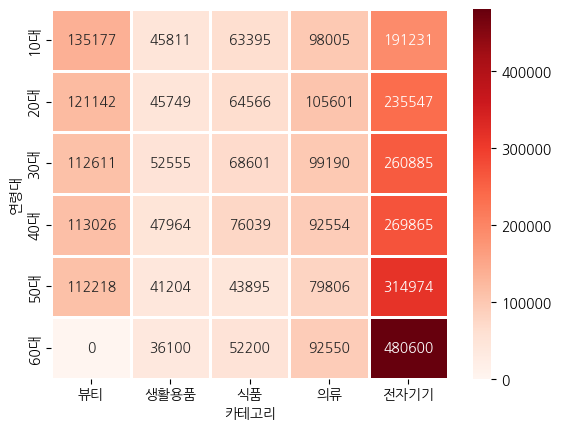

In [160]:
sns.heatmap(data= df_6, cmap='Reds', annot=True, fmt='.0f', linewidths=0.8)
plt.show()

### 문제 4. 유입채널별 성과

`유입채널`별로:
1. 주문 건수
2. 총 매출
3. 평균 평점

세 지표를 한번에 구하고, 유입채널별 총 매출을 막대그래프로 그리세요.


In [162]:
df['유입채널'].value_counts()

유입채널
검색      672
SNS     534
직접방문    390
이메일     233
제휴      171
Name: count, dtype: int64

In [171]:
df_7 = df.groupby('유입채널').agg(주문건수=('주문ID', 'count'), 총매출=('매출', 'sum'), 평균평점=('평점', 'mean')).round(2).sort_values('총매출', ascending=False) 

In [173]:
df_7

,주문건수,총매출,평균평점
유입채널,,,
검색,672,85490819.32,2.77
SNS,534,61307007.78,2.82
직접방문,390,46517063.63,2.76
이메일,233,25396400.32,3.15
제휴,171,21399573.89,3.02


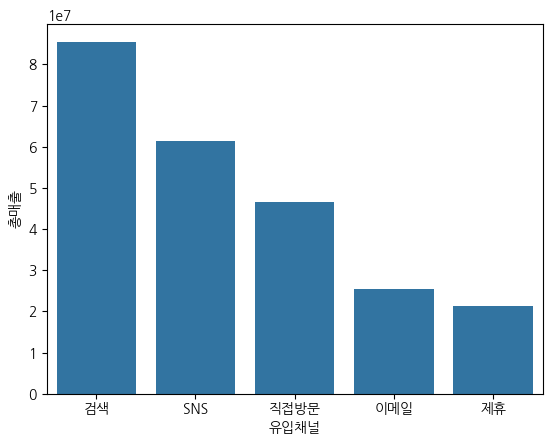

In [175]:
sns.barplot(x=df_7.index, y=df_7['총매출'] )
plt.show()

In [ ]:
# 아래에 코드를 작성하세요
